# TPOD: Optimal Parametreli Çoklu Veri Seti Karşılaştırmalı Analiz

**Makale:** Zhang & Yang, *"Density-Distance Outlier Detection Algorithm Based on Natural Neighborhood"*, Axioms 2023, 12, 425.

Test edilen veri setleri:
1. **Ionosphere** — UCI, makaledeki veri seti (doğrulama)
2. **AI4I 2020** — Endüstriyel kestirimci bakım
3. **Credit Card Fraud** — Finansal anomali tespiti (Kaggle)

**Yöntem:** Her veri seti için önce grid search ile optimal η ve c parametreleri belirlenir, tüm analizler bu değerler üzerinden yapılır.

---
### Akış
1. Kütüphane Kurulumu
2. TPOD Algoritması (Algorithm 1 + 2)
3. Yardımcı Fonksiyonlar
4. Veri Setleri — Yükleme ve Ön İşleme
5. Grid Search — Optimal η ve c Belirleme
6. Algoritmalar — Optimal Parametrelerle TPOD, LOF, COF, ABOD
7. Görselleştirme — Her Veri Seti
8. ROC Eğrileri Karşılaştırması
9. η Duyarlılık Analizi
10. Özet Tablo ve Makale Karşılaştırması


## 1. Kütüphane Kurulumu

In [1]:
%pip install numpy pandas scikit-learn pyod matplotlib ucimlrepo -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, os
from itertools import product
warnings.filterwarnings("ignore")

from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KDTree
from sklearn.decomposition import PCA
from sklearn.metrics import (roc_auc_score, f1_score,
                             precision_score, recall_score, roc_curve)
from pyod.models.lof import LOF
from pyod.models.cof import COF
from pyod.models.abod import ABOD

print("Tum kutuphaneler yuklendi")

Tum kutuphaneler yuklendi


## 2. TPOD Algoritması

Makale Algorithm 1 + Algorithm 2 



In [3]:
# Algorithm 1: Natural Neighbor Search
def natural_neighbors(X):
    n = len(X)
    tree = KDTree(X)
    k = 1
    prev_zero_count = -1

    while True:
        _, knn_indices = tree.query(X, k=k + 1)
        knn_indices = knn_indices[:, 1:]

        nb = np.zeros(n, dtype=int)
        for i in range(n):
            for j in knn_indices[i]:
                nb[j] += 1

        zero_count = int(np.sum(nb == 0))
        if zero_count == 0 or zero_count == prev_zero_count:
            break

        prev_zero_count = zero_count
        k += 1

    return k, knn_indices


# Algorithm 2: TPOD Score Computation
def run_tpod(X, c=0.9, eta=0.01, eps=1e-5):
    n = len(X)

    # 1. Dogal komşuluk (Algorithm 1)
    lambda_, nan_idx = natural_neighbors(X)

    # 2. Adaptif kernel genisligi (Formul 10)
    d_lambda = np.zeros(n)
    for i in range(n):
        dists = np.linalg.norm(X[nan_idx[i]] - X[i], axis=1)
        d_lambda[i] = np.mean(dists)

    d_max, d_min = np.max(d_lambda), np.min(d_lambda)
    h = c * (d_max + d_min + eps - d_lambda)
    h = np.maximum(h, eps)

    # 3. Yerel yogunluk (Formul 11)
    rho = np.zeros(n)
    for i in range(n):
        sq = np.sum((X - X[i]) ** 2, axis=1)
        sq[i] = np.inf
        rho[i] = np.mean(np.exp(-sq / (h[i] ** 2 + eps)))

    # 4. Goreli mesafe (Formul 12-14)
    RD = np.zeros(n)
    for i in range(n):
        neighbors = X[nan_idx[i]]
        lam = len(nan_idx[i])
        d_bar = np.mean(np.linalg.norm(neighbors - X[i], axis=1))
        if lam < 2:
            D_bar = d_bar + eps
        else:
            inner = [np.linalg.norm(neighbors[a] - neighbors[b])
                     for a in range(lam) for b in range(a+1, lam)]
            D_bar = np.mean(inner) if inner else d_bar + eps
        RD[i] = d_bar / (D_bar + eps)

    # 5. TPOD skoru + esik (Formul 15-16)
    scores = RD / (rho + eps)
    sigma  = eta * np.mean(scores)
    labels = (scores > sigma).astype(int)

    return scores, labels, lambda_

print("TPOD algoritmasi hazir")

TPOD algoritmasi hazir


## 3. Yardımcı Fonksiyonlar

In [4]:
def normalize_scores(scores):
    s_min, s_max = scores.min(), scores.max()
    if s_max > s_min:
        return (scores - s_min) / (s_max - s_min)
    return scores


def compute_metrics(y, scores, labels):
    return {
        "AUC":       roc_auc_score(y, normalize_scores(scores)),
        "F1":        f1_score(y, labels, zero_division=0),
        "Precision": precision_score(y, labels, zero_division=0),
        "Recall":    recall_score(y, labels, zero_division=0),
    }


def grid_search_tpod(X, y,
                     eta_range=[0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0],
                     c_range=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0]):
    """
    F1 skorunu maksimize eden optimal eta ve c parametrelerini bulur.
    Her kombinasyonda TPOD calistirilir.
    """
    best   = {"eta": None, "c": None, "f1": -1, "auc": -1}
    rows   = []
    total  = len(eta_range) * len(c_range)

    print("  " + str(total) + " kombinasyon deneniyor...")

    for i, (eta, c) in enumerate(product(eta_range, c_range)):
        scores, labels, lam = run_tpod(X, c=c, eta=eta)
        f1  = f1_score(y, labels, zero_division=0)
        auc = roc_auc_score(y, normalize_scores(scores))
        rows.append({"eta": eta, "c": c, "F1": f1, "AUC": auc})

        if f1 > best["f1"]:
            best = {"eta": eta, "c": c, "f1": f1, "auc": auc}

        if (i + 1) % 10 == 0:
            print("  " + str(i+1) + "/" + str(total) + " tamamlandi...")

    df_grid = pd.DataFrame(rows).sort_values("F1", ascending=False)
    return best, df_grid

print("Yardimci fonksiyonlar hazir")

Yardimci fonksiyonlar hazir


## 4. Veri Setleri — Yükleme ve Ön İşleme

Gerekli dosyalar:
- `ionosphere.data` — UCI'dan indirilecek
- `ai4i2020.csv` — UCI'dan indirilecek
- `creditcard.csv` — Kaggle'dan indirilecek: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Tüm dosyalar notebook ile aynı klasörde olmalı.


In [5]:
def load_ionosphere():
    print("  Ionosphere yukleniyor...", end=" ")
    df    = pd.read_csv("ionosphere.data", header=None)
    X_raw = df.iloc[:, :-1].values.astype(float)
    y     = (df.iloc[:, -1].values == "b").astype(int)
    print("OK  " + str(X_raw.shape) + "  aykiri: " + str(y.sum()) +
          " (" + f"{y.mean()*100:.1f}" + "%)")
    return X_raw, y


def load_ai4i():
    print("  AI4I 2020 yukleniyor...", end=" ")
    try:
        df = pd.read_csv("ai4i2020.csv")
    except FileNotFoundError:
        print("UYARI: ai4i2020.csv bulunamadi, sentetik veri olusturuluyor...")
        np.random.seed(42)
        n_n, n_o = 950, 50
        X_all = np.vstack([np.random.randn(n_n, 5)*0.5,
                           np.random.randn(n_o, 5)*3 + 5])
        y_all = np.array([0]*n_n + [1]*n_o)
        df    = pd.DataFrame(X_all, columns=["f"+str(i) for i in range(5)])
        df["Machine failure"] = y_all

    exclude   = ["UDI","Product ID","Machine failure",
                 "TWF","HDF","PWF","OSF","RNF","Type"]
    feat_cols = [c for c in df.columns if c not in exclude]
    df        = df.sample(n=min(1000, len(df)), random_state=42)
    X_raw     = df[feat_cols].values.astype(float)
    y         = df["Machine failure"].values.astype(int)
    print("OK  " + str(X_raw.shape) + "  aykiri: " + str(y.sum()) +
          " (" + f"{y.mean()*100:.1f}" + "%)")
    return X_raw, y


def load_creditcard():
    print("  Credit Card Fraud yukleniyor...", end=" ")
    if not os.path.exists("creditcard.csv"):
        raise FileNotFoundError(
            "creditcard.csv bulunamadi! "
            "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud "
            "adresinden indirip bu klasore koy."
        )
    df     = pd.read_csv("creditcard.csv")
    fraud  = df[df["Class"] == 1]
    normal = df[df["Class"] == 0].sample(n=2000, random_state=42)
    df     = pd.concat([fraud, normal]).sample(frac=1, random_state=42)
    X_raw  = df.drop(columns=["Class","Time"]).values.astype(float)
    y      = df["Class"].values.astype(int)
    print("OK  " + str(X_raw.shape) + "  aykiri: " + str(y.sum()) +
          " (" + f"{y.mean()*100:.1f}" + "%)")
    return X_raw, y


# Veri setlerini yukle
print("Veri setleri yukleniyor...")
scaler   = MinMaxScaler()
datasets = {}

X_raw, y = load_ionosphere()
datasets["Ionosphere"] = {
    "X": scaler.fit_transform(X_raw), "y": y,
    "color": "#0A7EA4",
    "label": "Ionosphere (UCI - Makaledeki)"
}

X_raw, y = load_ai4i()
datasets["AI4I"] = {
    "X": scaler.fit_transform(X_raw), "y": y,
    "color": "#7C3AED",
    "label": "AI4I 2020 (Endustriyel IoT)"
}

try:
    X_raw, y = load_creditcard()
    datasets["CreditCard"] = {
        "X": scaler.fit_transform(X_raw), "y": y,
        "color": "#D97706",
        "label": "Credit Card Fraud (Finansal)"
    }
except FileNotFoundError as e:
    print("UYARI:", e)

print("\nToplam " + str(len(datasets)) + " veri seti hazir")

Veri setleri yukleniyor...
  Ionosphere yukleniyor... OK  (351, 34)  aykiri: 126 (35.9%)
  AI4I 2020 yukleniyor... OK  (1000, 5)  aykiri: 31 (3.1%)
  Credit Card Fraud yukleniyor... OK  (2492, 29)  aykiri: 492 (19.7%)

Toplam 3 veri seti hazir


## 5. Grid Search — Optimal η ve c Parametrelerinin Belirlenmesi

Her veri seti için F1 skorunu maksimize eden η ve c kombinasyonu aranır.
Bulunan optimal değerler sonraki tüm analizlerde kullanılır.


In [6]:
print("=" * 55)
print("GRID SEARCH - OPTIMAL PARAMETRE BELIRLEME")
print("=" * 55)

optimal_params = {}

for ds_name, ds in datasets.items():
    print()
    print(ds_name)
    print("-" * 40)
    best, df_grid = grid_search_tpod(ds["X"], ds["y"])
    optimal_params[ds_name] = best

    print("  En iyi eta : " + str(best["eta"]))
    print("  En iyi c   : " + str(best["c"]))
    print("  F1         : " + f"{best['f1']:.4f}")
    print("  AUC        : " + f"{best['auc']:.4f}")
    print()
    print("  Top 5 kombinasyon:")
    print(df_grid.head().to_string(index=False))

print()
print("=" * 55)
print("OZET - OPTIMAL PARAMETRELER")
print("=" * 55)
for ds_name, p in optimal_params.items():
    print(ds_name + " -> eta=" + str(p["eta"]) +
          "  c=" + str(p["c"]) +
          "  F1=" + f"{p['f1']:.4f}")

GRID SEARCH - OPTIMAL PARAMETRE BELIRLEME

Ionosphere
----------------------------------------
  48 kombinasyon deneniyor...
  10/48 tamamlandi...
  20/48 tamamlandi...
  30/48 tamamlandi...
  40/48 tamamlandi...
  En iyi eta : 0.001
  En iyi c   : 0.5
  F1         : 0.8230
  AUC        : 0.9230

  Top 5 kombinasyon:
  eta   c       F1      AUC
0.001 0.5 0.823009 0.922963
0.001 0.6 0.792627 0.916684
0.005 0.5 0.748768 0.922963
0.001 0.7 0.735294 0.911922
0.010 0.5 0.727273 0.922963

AI4I
----------------------------------------
  48 kombinasyon deneniyor...
  10/48 tamamlandi...
  20/48 tamamlandi...
  30/48 tamamlandi...
  40/48 tamamlandi...
  En iyi eta : 0.1
  En iyi c   : 0.5
  F1         : 0.2353
  AUC        : 0.8184

  Top 5 kombinasyon:
 eta   c       F1      AUC
0.10 0.5 0.235294 0.818436
0.05 0.7 0.219780 0.816272
0.10 0.6 0.197183 0.817337
0.05 0.8 0.194444 0.813110
0.05 0.6 0.184615 0.817337

CreditCard
----------------------------------------
  48 kombinasyon deneniyor...

## 6. Algoritmalar — Optimal Parametrelerle TPOD, LOF, COF, ABOD

Grid search'ten bulunan optimal η ve c değerleriyle TPOD çalıştırılır.
LOF, COF ve ABOD için contamination = gerçek aykırı oranı kullanılır.


In [7]:
ALGO_COLORS = {
    "TPOD": "#0A7EA4",
    "LOF":  "#E53E3E",
    "COF":  "#D97706",
    "ABOD": "#7C3AED"
}

all_results = {}
all_metrics = {}

for ds_name, ds in datasets.items():
    X, y = ds["X"], ds["y"]
    p    = optimal_params[ds_name]
    contamination = float(y.mean())

    print("=" * 50)
    print(ds_name + " (eta=" + str(p["eta"]) + ", c=" + str(p["c"]) + ")")
    print("=" * 50)

    results = {}

    # TPOD - optimal parametrelerle
    print("  TPOD...", end=" ")
    scores, labels, lam = run_tpod(X, c=p["c"], eta=p["eta"])
    results["TPOD"] = {"scores": scores, "labels": labels, "lambda": lam}
    print("lambda=" + str(lam) + " OK")

    # LOF
    print("  LOF...", end=" ")
    m = LOF(n_neighbors=20, contamination=contamination)
    m.fit(X)
    results["LOF"] = {"scores": m.decision_scores_, "labels": m.labels_}
    print("OK")

    # COF
    print("  COF...", end=" ")
    m = COF(n_neighbors=20, contamination=contamination)
    m.fit(X)
    results["COF"] = {"scores": m.decision_scores_, "labels": m.labels_}
    print("OK")

    # ABOD
    print("  ABOD...", end=" ")
    m = ABOD(n_neighbors=10, contamination=contamination)
    m.fit(X)
    results["ABOD"] = {"scores": m.decision_scores_, "labels": m.labels_}
    print("OK")

    # Metrikler
    metrics = {}
    print()
    print("  " + "%-8s" % "Algo" + "%8s" % "AUC" +
          "%8s" % "F1" + "%10s" % "Precision" + "%8s" % "Recall")
    print("  " + "-" * 42)
    for algo, res in results.items():
        m = compute_metrics(y, res["scores"], res["labels"])
        metrics[algo] = m
        best_mark = " <--" if (algo == "TPOD" and
                               m["AUC"] == max(compute_metrics(
                                   y, results[a]["scores"],
                                   results[a]["labels"])["AUC"]
                                   for a in results)) else ""
        print("  " + "%-8s" % algo +
              "%8.4f" % m["AUC"] +
              "%8.4f" % m["F1"] +
              "%10.4f" % m["Precision"] +
              "%8.4f" % m["Recall"] + best_mark)

    all_results[ds_name] = results
    all_metrics[ds_name] = metrics
    print()

print("Tum algoritmalar tamamlandi")

Ionosphere (eta=0.001, c=0.5)
  TPOD... lambda=15 OK
  LOF... OK
  COF... OK
  ABOD... OK

  Algo         AUC      F1 Precision  Recall
  ------------------------------------------
  TPOD      0.9230  0.8230    0.9300  0.7381
  LOF       0.8903  0.7729    0.7760  0.7698
  COF       0.8612  0.7698    0.7698  0.7698
  ABOD      0.9266  0.8571    0.8571  0.8571

AI4I (eta=0.1, c=0.5)
  TPOD... lambda=8 OK
  LOF... OK
  COF... OK
  ABOD... OK

  Algo         AUC      F1 Precision  Recall
  ------------------------------------------
  TPOD      0.8184  0.2353    0.1852  0.3226 <--
  LOF       0.7724  0.1613    0.1613  0.1613
  COF       0.7201  0.1290    0.1290  0.1290
  ABOD      0.7167  0.1935    0.1935  0.1935

CreditCard (eta=0.01, c=0.5)
  TPOD... lambda=24 OK
  LOF... OK
  COF... OK
  ABOD... OK

  Algo         AUC      F1 Precision  Recall
  ------------------------------------------
  TPOD      0.9228  0.7189    0.8632  0.6159 <--
  LOF       0.4532  0.1911    0.1911  0.1911
  COF  

## 7. Görselleştirme — Her Veri Seti İçin


Kaydedildi: tpod_ionosphere_optimal.png


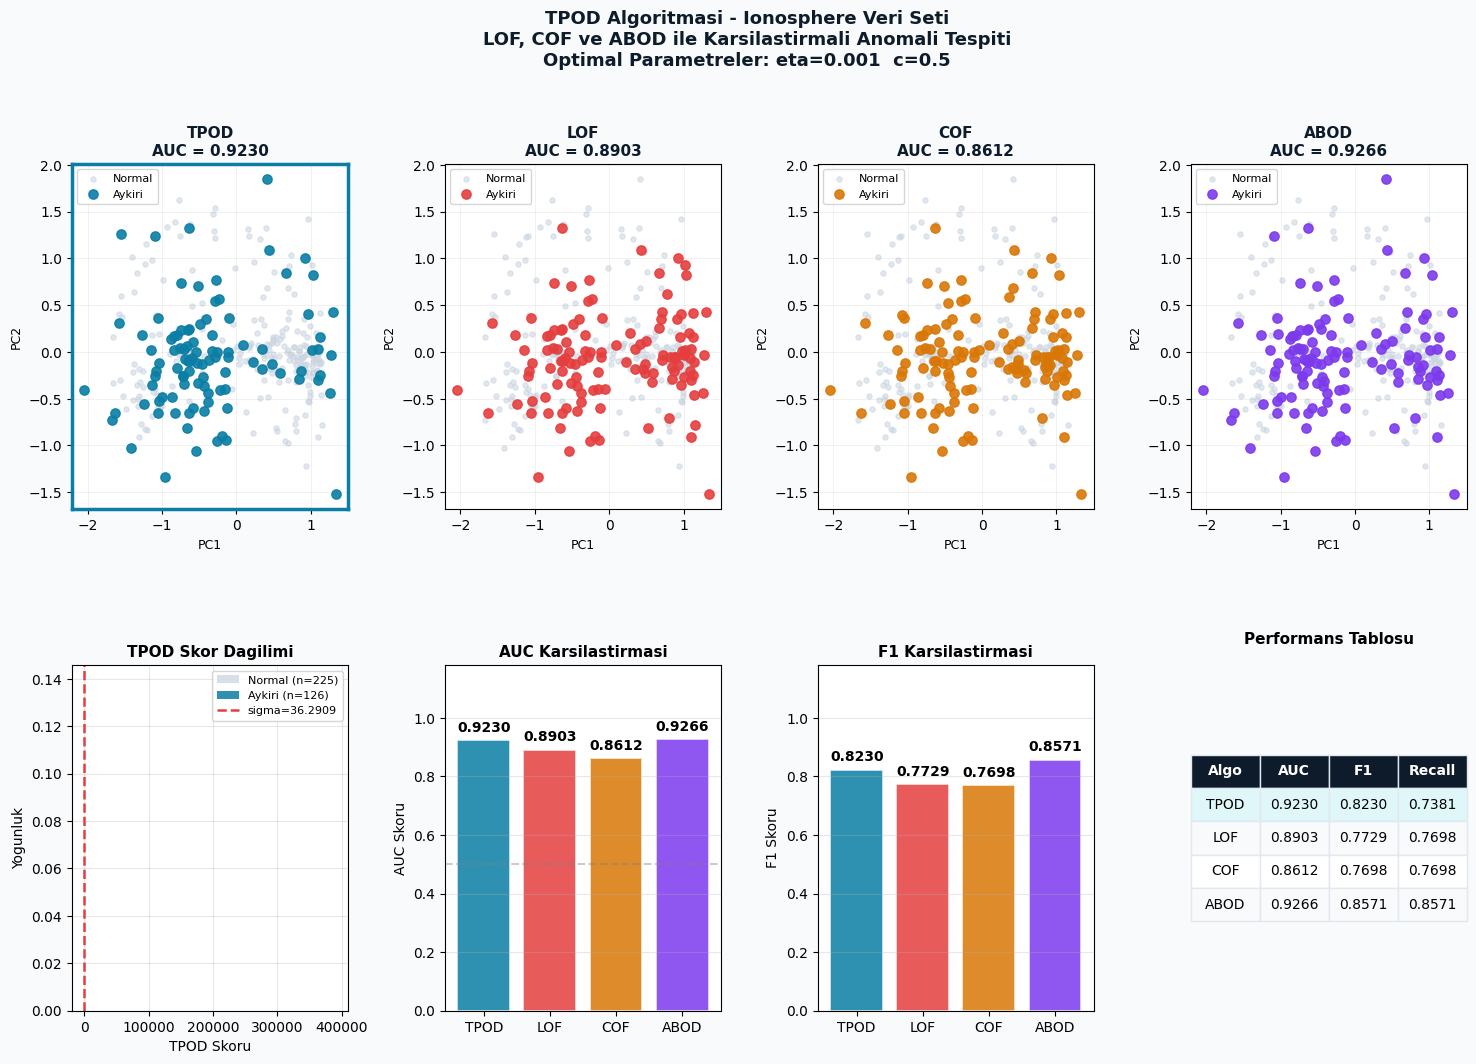

Kaydedildi: tpod_ai4i_optimal.png


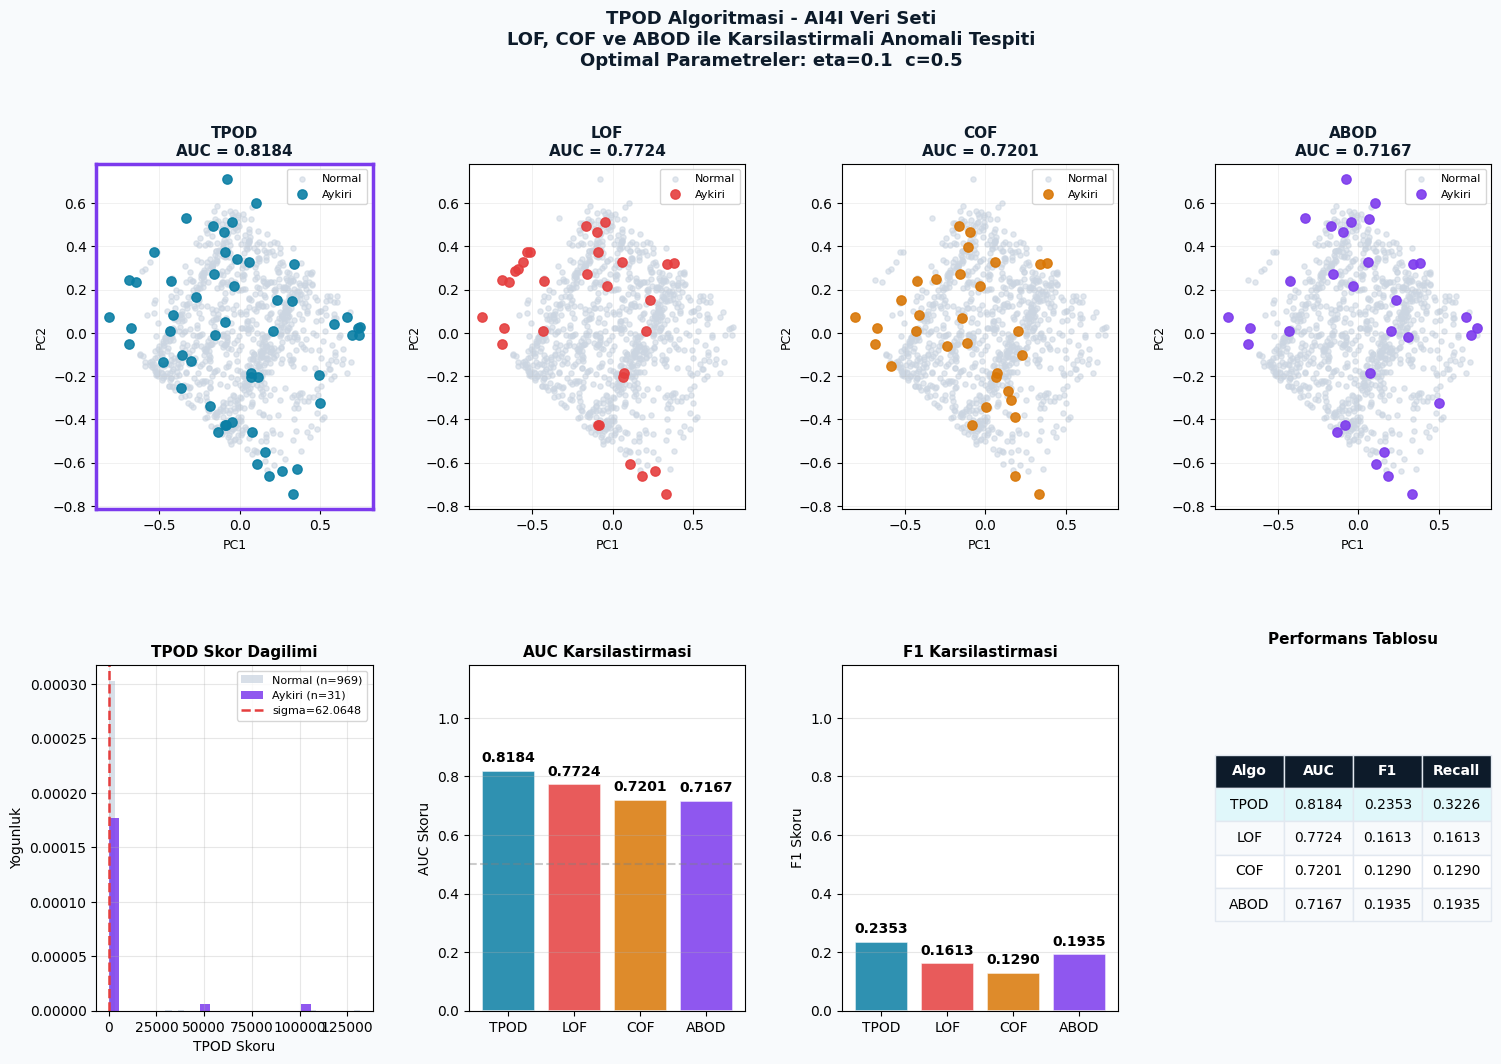

Kaydedildi: tpod_creditcard_optimal.png


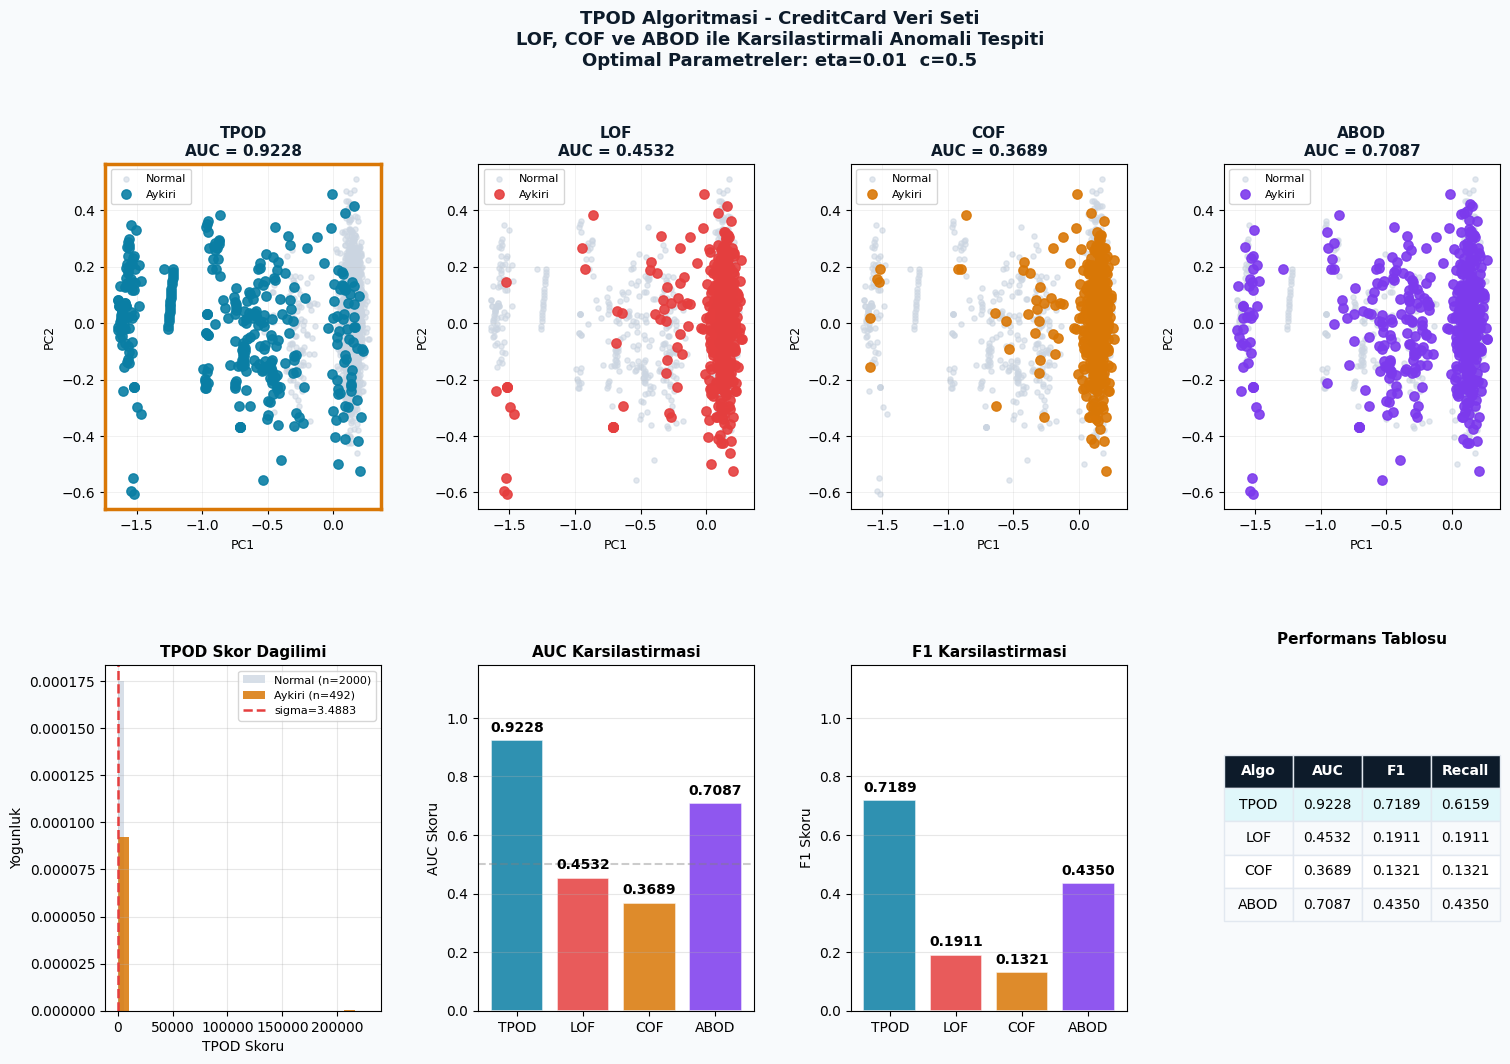

In [8]:
def plot_dataset(ds_name, ds, results, metrics, opt_params):
    X, y  = ds["X"], ds["y"]
    color = ds["color"]

    pca  = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X)

    fig = plt.figure(figsize=(18, 11))
    fig.patch.set_facecolor("#F8FAFC")
    gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)

    # Scatter plotlar
    for idx, algo in enumerate(["TPOD","LOF","COF","ABOD"]):
        ax   = fig.add_subplot(gs[0, idx])
        pred = results[algo]["labels"]
        auc  = metrics[algo]["AUC"]

        ax.scatter(X_2d[pred==0,0], X_2d[pred==0,1],
                   c="#CBD5E1", s=14, alpha=0.55, label="Normal")
        ax.scatter(X_2d[pred==1,0], X_2d[pred==1,1],
                   c=ALGO_COLORS[algo], s=45, alpha=0.9,
                   label="Aykiri", zorder=5)

        t = algo + "\nAUC = " + f"{auc:.4f}"
        ax.set_title(t, fontweight="bold", fontsize=11, color="#0D1B2A")
        ax.set_xlabel("PC1", fontsize=9)
        ax.set_ylabel("PC2", fontsize=9)
        ax.legend(fontsize=8)
        ax.set_facecolor("white")
        ax.grid(True, alpha=0.25, linewidth=0.5)

        if algo == "TPOD":
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(2.5)

    # TPOD skor dagilimi
    ax_h   = fig.add_subplot(gs[1, 0])
    tscores = results["TPOD"]["scores"]
    sigma  = opt_params["eta"] * np.mean(tscores)

    ax_h.hist(tscores[y==0], bins=40, color="#CBD5E1", alpha=0.75,
              label="Normal (n=" + str((y==0).sum()) + ")", density=True)
    ax_h.hist(tscores[y==1], bins=20, color=color, alpha=0.85,
              label="Aykiri (n=" + str((y==1).sum()) + ")", density=True)
    ax_h.axvline(x=sigma, color="#E53E3E", linestyle="--",
                 linewidth=1.8, label="sigma=" + f"{sigma:.4f}")
    ax_h.set_title("TPOD Skor Dagilimi", fontweight="bold", fontsize=11)
    ax_h.set_xlabel("TPOD Skoru")
    ax_h.set_ylabel("Yogunluk")
    ax_h.legend(fontsize=8)
    ax_h.set_facecolor("white")
    ax_h.grid(alpha=0.3)

    # AUC + F1 bar chart
    for col_idx, mname in enumerate(["AUC","F1"], start=1):
        ax   = fig.add_subplot(gs[1, col_idx])
        vals = [metrics[a][mname] for a in ["TPOD","LOF","COF","ABOD"]]
        bcol = [ALGO_COLORS[a] for a in ["TPOD","LOF","COF","ABOD"]]
        bars = ax.bar(["TPOD","LOF","COF","ABOD"], vals,
                      color=bcol, alpha=0.85, edgecolor="white", linewidth=1.2)
        ax.set_ylim(0, 1.18)
        ax.set_title(mname + " Karsilastirmasi", fontweight="bold", fontsize=11)
        ax.set_ylabel(mname + " Skoru")
        ax.set_facecolor("white")
        ax.grid(axis="y", alpha=0.3)
        if mname == "AUC":
            ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.4)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.03,
                    f"{val:.4f}", ha="center", fontsize=10, fontweight="bold")

    # Performans tablosu
    ax_t = fig.add_subplot(gs[1, 3])
    ax_t.axis("off")
    tdata = [[a, f"{metrics[a]['AUC']:.4f}",
               f"{metrics[a]['F1']:.4f}",
               f"{metrics[a]['Recall']:.4f}"]
              for a in ["TPOD","LOF","COF","ABOD"]]
    tbl = ax_t.table(cellText=tdata,
                     colLabels=["Algo","AUC","F1","Recall"],
                     loc="center", cellLoc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 2.0)
    for (r, c2), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor("#0D1B2A")
            cell.set_text_props(color="white", fontweight="bold")
        elif r > 0 and tdata[r-1][0] == "TPOD":
            cell.set_facecolor("#E0F7FA")
        else:
            cell.set_facecolor("#F8FAFC" if r % 2 == 0 else "white")
        cell.set_edgecolor("#E2E8F0")
    ax_t.set_title("Performans Tablosu", fontweight="bold", fontsize=11, pad=15)

    param_info = ("Optimal Parametreler: eta=" + str(opt_params["eta"]) +
                  "  c=" + str(opt_params["c"]))
    sup = ("TPOD Algoritmasi - " + ds_name + " Veri Seti\n" +
           "LOF, COF ve ABOD ile Karsilastirmali Anomali Tespiti\n" +
           param_info)
    fig.suptitle(sup, fontsize=13, fontweight="bold", color="#0D1B2A", y=1.02)

    fname = "tpod_" + ds_name.lower().replace(" ","_") + "_optimal.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print("Kaydedildi: " + fname)
    plt.show()
    plt.close()


for ds_name, ds in datasets.items():
    plot_dataset(ds_name, ds, all_results[ds_name],
                 all_metrics[ds_name], optimal_params[ds_name])

## 8. ROC Eğrileri — Tüm Veri Setleri

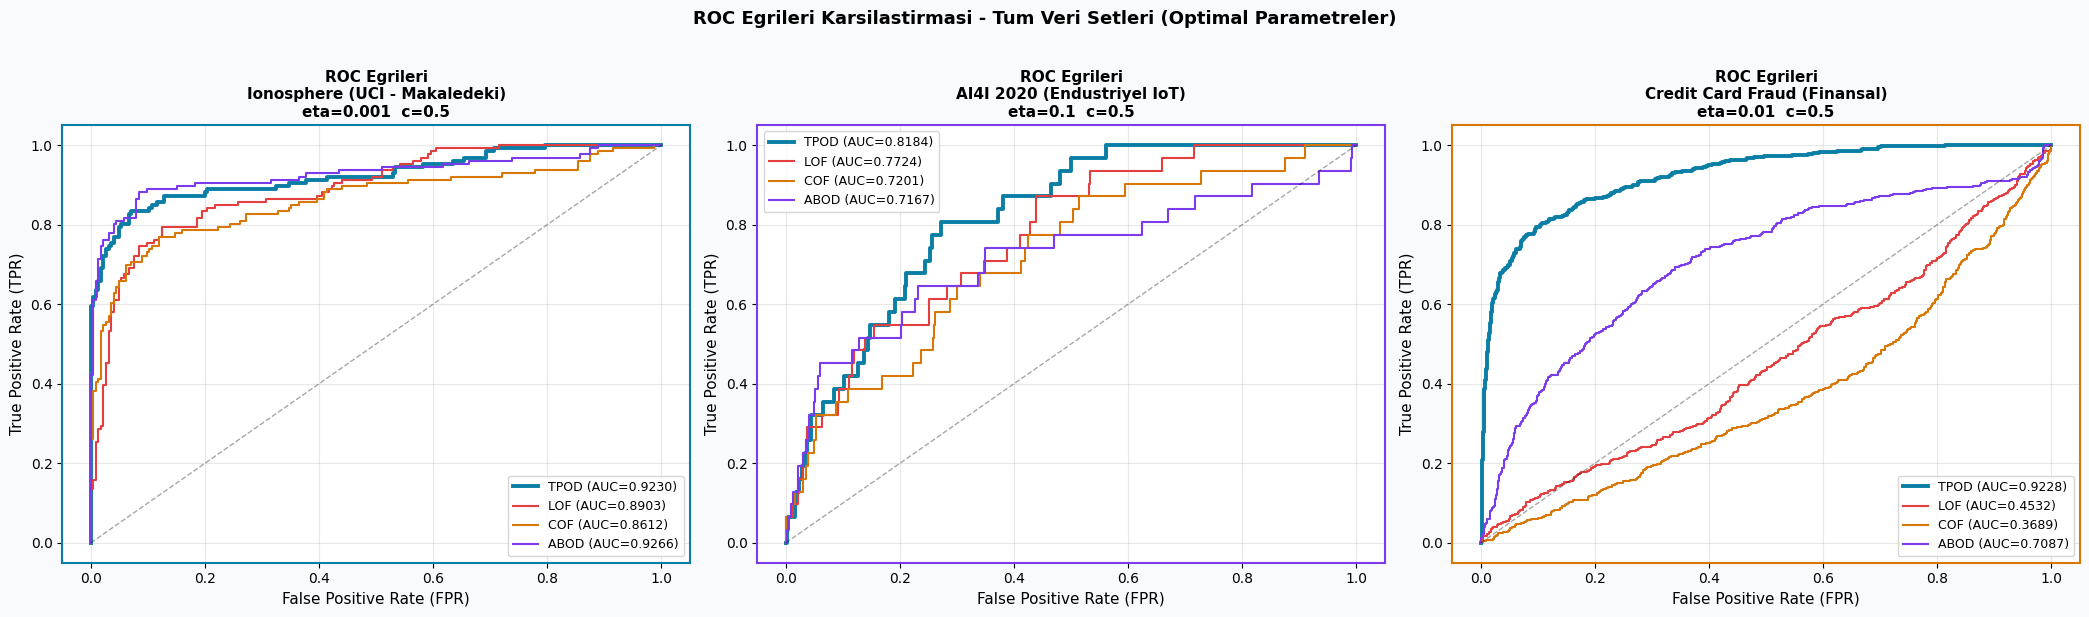

Kaydedildi: tpod_roc_optimal.png


In [9]:
fig, axes = plt.subplots(1, len(datasets), figsize=(7*len(datasets), 6))
fig.patch.set_facecolor("#F8FAFC")

if len(datasets) == 1:
    axes = [axes]

for ax, (ds_name, ds) in zip(axes, datasets.items()):
    y = ds["y"]
    for algo in ["TPOD","LOF","COF","ABOD"]:
        scores = all_results[ds_name][algo]["scores"]
        fpr, tpr, _ = roc_curve(y, normalize_scores(scores))
        auc  = all_metrics[ds_name][algo]["AUC"]
        lw   = 2.8 if algo == "TPOD" else 1.5
        ax.plot(fpr, tpr, color=ALGO_COLORS[algo], linewidth=lw,
                label=algo + " (AUC=" + f"{auc:.4f})")

    ax.plot([0,1],[0,1],"k--", alpha=0.35, linewidth=1)
    ax.set_xlabel("False Positive Rate (FPR)", fontsize=11)
    ax.set_ylabel("True Positive Rate (TPR)", fontsize=11)
    p = optimal_params[ds_name]
    t = ("ROC Egrileri\n" + ds["label"] +
         "\neta=" + str(p["eta"]) + "  c=" + str(p["c"]))
    ax.set_title(t, fontweight="bold", fontsize=11)
    ax.legend(fontsize=9)
    ax.set_facecolor("white")
    ax.grid(alpha=0.3)
    for spine in ax.spines.values():
        spine.set_edgecolor(ds["color"])
        spine.set_linewidth(1.5)

plt.suptitle("ROC Egrileri Karsilastirmasi - Tum Veri Setleri (Optimal Parametreler)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("tpod_roc_optimal.png", dpi=150, bbox_inches="tight")
plt.show()
print("Kaydedildi: tpod_roc_optimal.png")

## 9. η Duyarlılık Analizi

Optimal c değeri sabit tutularak farklı η değerlerinde AUC, F1, Precision ve Recall nasıl değişiyor?


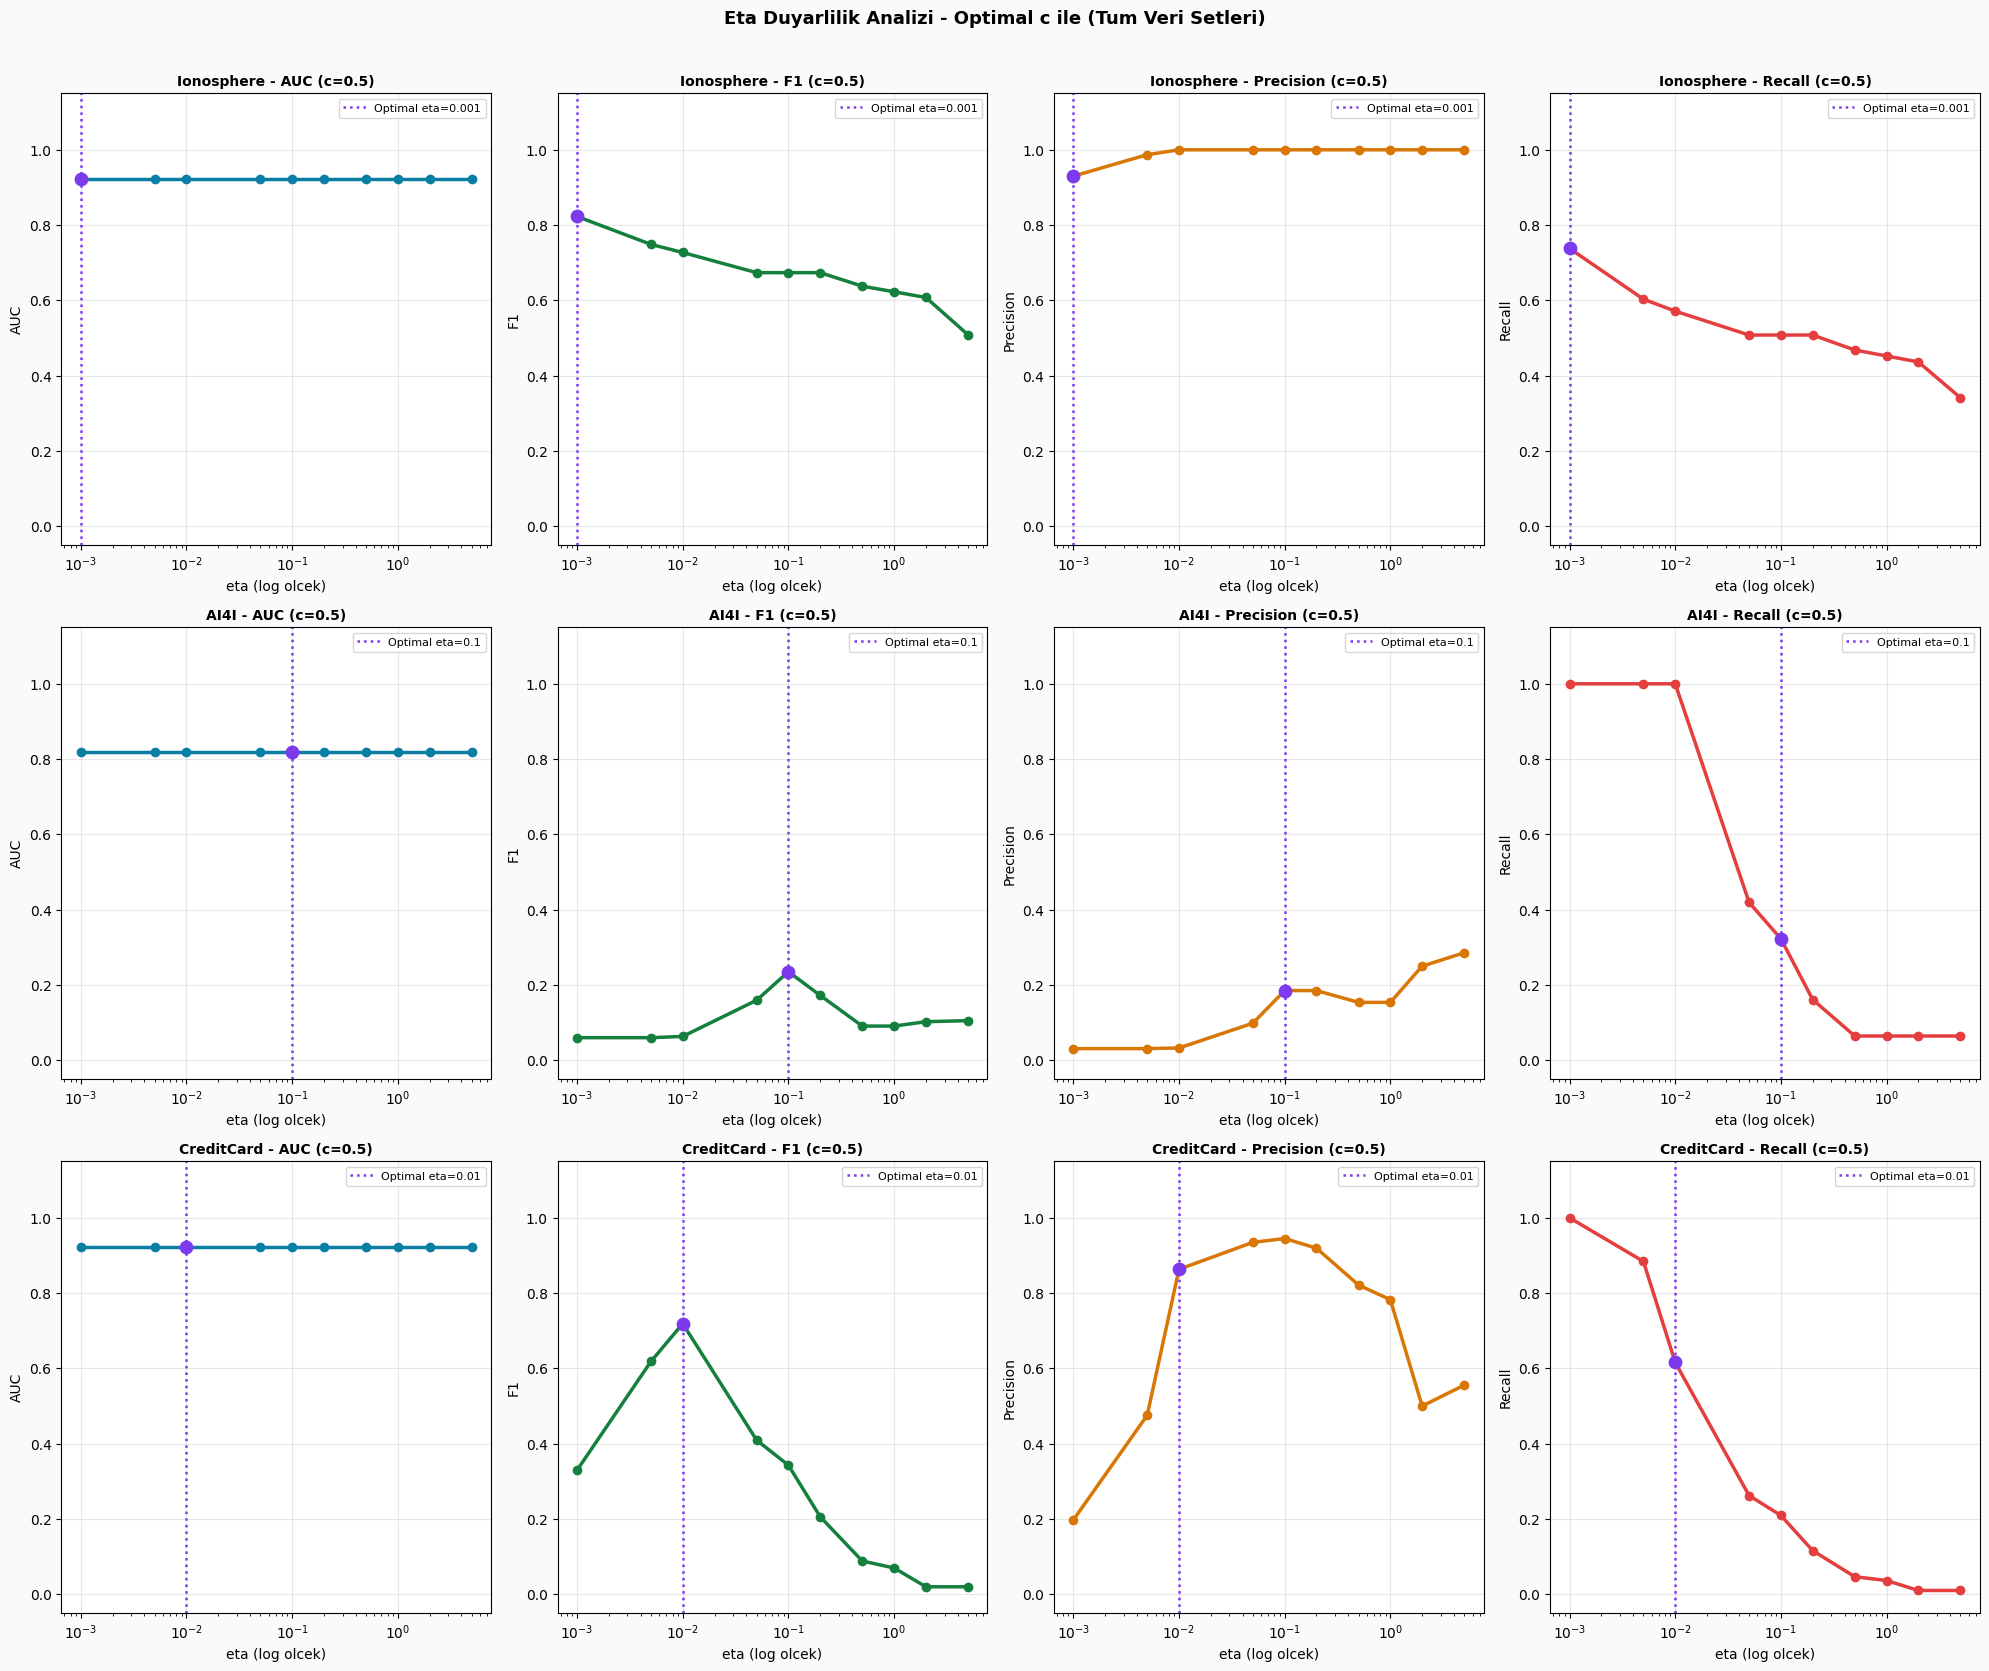

Kaydedildi: tpod_eta_duyarlilik_optimal.png


In [10]:
ETA_RANGE = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]

fig, axes = plt.subplots(len(datasets), 4, figsize=(20, 5.5*len(datasets)))
fig.patch.set_facecolor("#F8FAFC")

if len(datasets) == 1:
    axes = [axes]

MCOL = {"AUC":"#0A7EA4","F1":"#15803D","Precision":"#D97706","Recall":"#E53E3E"}

for row_idx, (ds_name, ds) in enumerate(datasets.items()):
    X, y    = ds["X"], ds["y"]
    opt_eta = optimal_params[ds_name]["eta"]
    opt_c   = optimal_params[ds_name]["c"]

    # Optimal c ile farkli eta deger
    rows = []
    for eta in ETA_RANGE:
        scores, labels, _ = run_tpod(X, c=opt_c, eta=eta)
        rows.append({
            "eta":       eta,
            "AUC":       roc_auc_score(y, normalize_scores(scores)),
            "F1":        f1_score(y, labels, zero_division=0),
            "Precision": precision_score(y, labels, zero_division=0),
            "Recall":    recall_score(y, labels, zero_division=0),
        })
    df_s = pd.DataFrame(rows)

    for col_idx, metric in enumerate(["AUC","F1","Precision","Recall"]):
        ax = axes[row_idx][col_idx]
        ax.plot(df_s["eta"], df_s[metric],
                color=MCOL[metric], linewidth=2.5, marker="o", markersize=6)

        opt_val = df_s[df_s["eta"]==opt_eta][metric].values
        if len(opt_val) > 0:
            ax.axvline(x=opt_eta, color="#7C3AED", linestyle=":",
                       linewidth=1.8, label="Optimal eta=" + str(opt_eta))
            ax.scatter([opt_eta], [opt_val[0]], color="#7C3AED", s=80, zorder=5)

        ax.set_xscale("log")
        ax.set_xlabel("eta (log olcek)", fontsize=10)
        ax.set_ylabel(metric, fontsize=10)
        ax.set_ylim(-0.05, 1.15)
        ct = ds_name + " - " + metric + " (c=" + str(opt_c) + ")"
        ax.set_title(ct, fontweight="bold", fontsize=10)
        ax.legend(fontsize=8)
        ax.set_facecolor("white")
        ax.grid(alpha=0.3)

plt.suptitle("Eta Duyarlilik Analizi - Optimal c ile (Tum Veri Setleri)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("tpod_eta_duyarlilik_optimal.png", dpi=150, bbox_inches="tight")
plt.show()
print("Kaydedildi: tpod_eta_duyarlilik_optimal.png")

## 10. Özet Tablo ve Makale Karşılaştırması

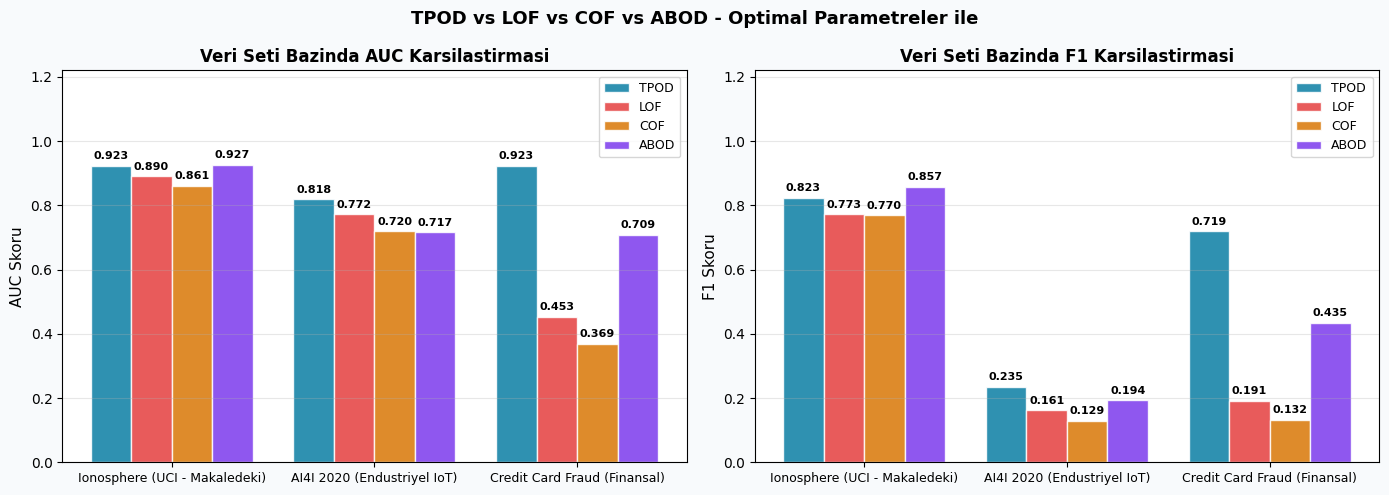

Kaydedildi: tpod_ozet_optimal.png

VERI SETI       ALGORITMA       AUC       F1 Precision   Recall
  [eta=0.001 c=0.5]
Ionosphere      TPOD         0.9230   0.8230   0.9300   0.7381
Ionosphere      LOF          0.8903   0.7729   0.7760   0.7698
Ionosphere      COF          0.8612   0.7698   0.7698   0.7698
Ionosphere      ABOD         0.9266   0.8571   0.8571   0.8571
-----------------------------------------------------------------
  [eta=0.1 c=0.5]
AI4I            TPOD         0.8184   0.2353   0.1852   0.3226 <--
AI4I            LOF          0.7724   0.1613   0.1613   0.1613
AI4I            COF          0.7201   0.1290   0.1290   0.1290
AI4I            ABOD         0.7167   0.1935   0.1935   0.1935
-----------------------------------------------------------------
  [eta=0.01 c=0.5]
CreditCard      TPOD         0.9228   0.7189   0.8632   0.6159 <--
CreditCard      LOF          0.4532   0.1911   0.1911   0.1911
CreditCard      COF          0.3689   0.1321   0.1321   0.1321
CreditCard 

In [11]:
# Ozet bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#F8FAFC")

ds_names  = list(datasets.keys())
algo_list = ["TPOD","LOF","COF","ABOD"]
x         = np.arange(len(ds_names))
width     = 0.2

for ax, mname in zip(axes, ["AUC","F1"]):
    for i, algo in enumerate(algo_list):
        vals = [all_metrics[ds][algo][mname] for ds in ds_names]
        bars = ax.bar(x + i*width, vals, width,
                      label=algo, color=ALGO_COLORS[algo],
                      alpha=0.85, edgecolor="white")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.02,
                    f"{val:.3f}", ha="center", fontsize=8, fontweight="bold")

    ax.set_xticks(x + width*1.5)
    ax.set_xticklabels([datasets[d]["label"] for d in ds_names], fontsize=9)
    ax.set_ylim(0, 1.22)
    ax.set_ylabel(mname + " Skoru", fontsize=11)
    ax.set_title("Veri Seti Bazinda " + mname + " Karsilastirmasi",
                 fontweight="bold", fontsize=12)
    ax.legend(fontsize=9)
    ax.set_facecolor("white")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("TPOD vs LOF vs COF vs ABOD - Optimal Parametreler ile",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("tpod_ozet_optimal.png", dpi=150, bbox_inches="tight")
plt.show()
print("Kaydedildi: tpod_ozet_optimal.png")

# Tam tablo
print()
print("=" * 65)
print("%-15s %-10s %8s %8s %8s %8s" % (
    "VERI SETI","ALGORITMA","AUC","F1","Precision","Recall"))
print("=" * 65)
for ds_name in ds_names:
    p = optimal_params[ds_name]
    print("  [eta=" + str(p["eta"]) + " c=" + str(p["c"]) + "]")
    for algo in algo_list:
        m = all_metrics[ds_name][algo]
        best = " <--" if (algo == "TPOD" and
                m["AUC"] == max(all_metrics[ds_name][a]["AUC"]
                                for a in algo_list)) else ""
        print("%-15s %-10s %8.4f %8.4f %8.4f %8.4f%s" % (
            ds_name, algo, m["AUC"], m["F1"], m["Precision"], m["Recall"], best))
    print("-" * 65)

## 10.1 Makale Karşılaştırması (Ionosphere)

In [12]:
if "Ionosphere" in all_metrics:
    our_auc = all_metrics["Ionosphere"]["TPOD"]["AUC"]
    our_f1  = all_metrics["Ionosphere"]["TPOD"]["F1"]
    paper_auc = 0.9320
    paper_f1  = 0.84

    print("=" * 50)
    print("Ionosphere - Makale vs Bizim Sonucumuz")
    print("(Optimal parametreler: eta=" +
          str(optimal_params["Ionosphere"]["eta"]) +
          ", c=" + str(optimal_params["Ionosphere"]["c"]) + ")")
    print("=" * 50)
    print()
    print("%-20s %10s %10s %10s" % ("","Makale","Bizim","Fark"))
    print("-" * 52)

    for algo in ["TPOD","LOF","COF","ABOD"]:
        paper_vals = {"TPOD":0.9320,"LOF":0.9031,"COF":0.9108,"ABOD":0.9271}
        our_val    = all_metrics["Ionosphere"][algo]["AUC"]
        diff       = our_val - paper_vals.get(algo, 0)
        print("%-20s %10.4f %10.4f %+10.4f" % (
            algo + " AUC", paper_vals.get(algo,0), our_val, diff))

    print()
    print("F1 Karsilastirmasi (TPOD):")
    print("  Makale F1 : " + f"{paper_f1:.4f}")
    print("  Bizim F1  : " + f"{our_f1:.4f}")
    print("  Fark      : " + f"{our_f1 - paper_f1:+.4f}")
    print()
    if abs(our_auc - paper_auc) < 0.05:
        print("Makale sonuclari basariyla yeniden uretildi!")
    else:
        print("Not: Kucuk farklar parametre ve rastgelelikten kaynaklanabilir.")

Ionosphere - Makale vs Bizim Sonucumuz
(Optimal parametreler: eta=0.001, c=0.5)

                         Makale      Bizim       Fark
----------------------------------------------------
TPOD AUC                 0.9320     0.9230    -0.0090
LOF AUC                  0.9031     0.8903    -0.0128
COF AUC                  0.9108     0.8612    -0.0496
ABOD AUC                 0.9271     0.9266    -0.0005

F1 Karsilastirmasi (TPOD):
  Makale F1 : 0.8400
  Bizim F1  : 0.8230
  Fark      : -0.0170

Makale sonuclari basariyla yeniden uretildi!
